# Exploration — signaux EMG Ninapro DB2, sujet 1

Avant d'entraîner quoi que ce soit : à quoi ressemble le signal, comment les gestes
sont répartis, et surtout **quels muscles s'activent pour quel geste** — c'est
cette information que la prothèse doit décoder.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import welch

sys.path.append("../src")
from data_loading import FS, PROCESSED_DIR, load_subject
from preprocessing import filter_emg
from gestures import ELECTRODES, gesture_name

DOCS = Path("../docs")

# Style sobre : grille discrète, encre neutre, couleurs réservées aux données
INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#f4f8fd", "#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "font.size": 10, "lines.linewidth": 1.2,
})

## 1. Chargement

In [2]:
npz = PROCESSED_DIR / "db2_s1.npz"
if npz.exists():
    d = np.load(npz)
    emg, labels, reps = d["emg"], d["labels"], d["repetitions"]
else:
    emg, labels, reps = load_subject(1, exercises=(1, 2, 3))

print(f"{emg.shape[0]:,} échantillons × {emg.shape[1]} électrodes "
      f"= {emg.shape[0] / FS / 60:.1f} min d'enregistrement à {FS} Hz")
print(f"{len(np.unique(labels)) - 1} mouvements, répétitions {sorted(set(np.unique(reps)) - {0})}")
print(f"Repos : {(labels == 0).mean():.0%} du temps")

5,238,692 échantillons × 12 électrodes = 43.7 min d'enregistrement à 2000 Hz


49 mouvements, répétitions [1, 2, 3, 4, 5, 6]
Repos : 54% du temps


## 2. Répartition des gestes

Chaque mouvement est tenu ~5 s puis relâché ~3 s, répété 6 fois. Le **repos**
domine largement : c'est pourquoi l'accuracy brute est trompeuse et qu'on suivra
l'**accuracy équilibrée** (moyenne des rappels par classe).

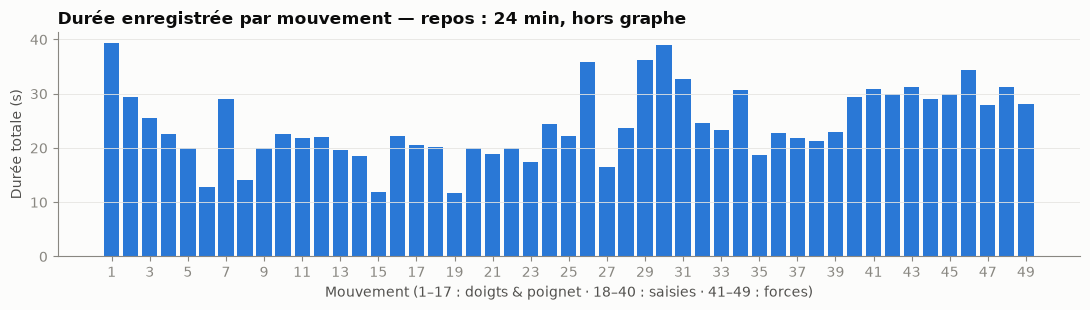

Durée par mouvement : 12–39 s (médiane 23 s)


In [3]:
ids, counts = np.unique(labels[labels > 0], return_counts=True)
secs = counts / FS

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(ids, secs, width=0.8, color=BLUE)
ax.set_xticks(ids[::2])
ax.set_xlabel("Mouvement (1–17 : doigts & poignet · 18–40 : saisies · 41–49 : forces)")
ax.set_ylabel("Durée totale (s)")
ax.set_title(f"Durée enregistrée par mouvement — repos : {(labels == 0).sum() / FS / 60:.0f} min, hors graphe")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()
print(f"Durée par mouvement : {secs.min():.0f}–{secs.max():.0f} s (médiane {np.median(secs):.0f} s)")

## 3. Filtrage : ce qu'on garde, ce qu'on enlève

L'EMG utile se situe entre ~20 et ~450 Hz. En dessous : artefacts de mouvement
des câbles et de la peau ; à 50 Hz : parasites du secteur. On compare le spectre
du signal brut et du signal filtré (passe-bande 20–450 Hz + coupe-bande 50 Hz).

Le signal Ninapro est déjà propre (pas de pic visible à 50 Hz, matériel Delsys
de qualité) : le coupe-bande est gardé comme sécurité pour des capteurs moins
chers, du type de ceux d'un prototype connecté.

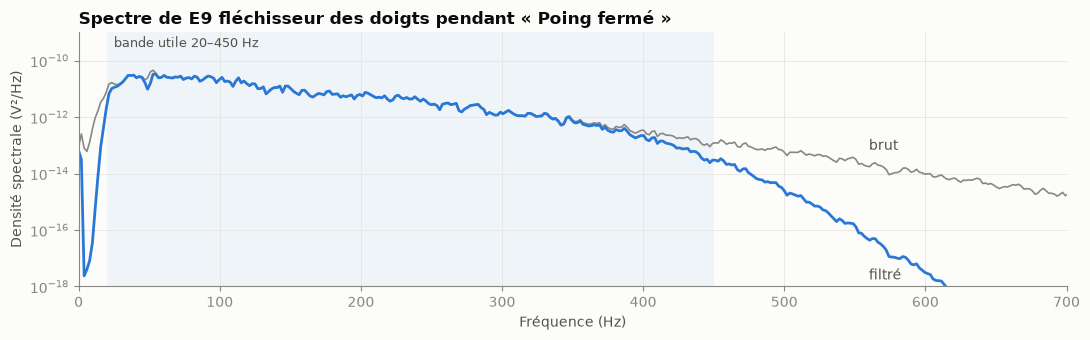

In [4]:
sel = labels == 6  # poing fermé
ch = 8               # E9, fléchisseur des doigts
raw = emg[sel, ch]
filt = filter_emg(emg[sel])[:, ch]

f, p_raw = welch(raw, fs=FS, nperseg=1024)
_, p_filt = welch(filt, fs=FS, nperseg=1024)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axvspan(20, 450, color=BLUE, alpha=0.06, lw=0)
ax.semilogy(f, p_raw, color=MUTED, lw=1.2)
ax.semilogy(f, p_filt, color=BLUE, lw=2)
ax.set_xlim(0, 700)
ax.set_ylim(1e-18, 1e-9)
ax.text(560, p_raw[f > 560][0] * 3, "brut", color=INK2, va="bottom")
ax.text(560, p_filt[f > 560][0] * 0.1, "filtré", color=INK2, va="top")
ax.text(25, 3e-10, "bande utile 20–450 Hz", color=INK2, fontsize=9)
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale (V²/Hz)")
ax.set_title(f"Spectre de {ELECTRODES[ch]} pendant « {gesture_name(6)} »")
plt.tight_layout()
fig.savefig(DOCS / "spectre_filtrage.png", dpi=150)
plt.show()

## 4. Le signal dans le temps

40 secondes de l'exercice 1, à la transition entre deux gestes, sur quatre électrodes. Les bandes grisées marquent les
périodes où le sujet exécute un mouvement : l'activité musculaire y monte
nettement, et **le motif d'activation diffère d'un geste à l'autre** — c'est ce
motif que le modèle apprend.

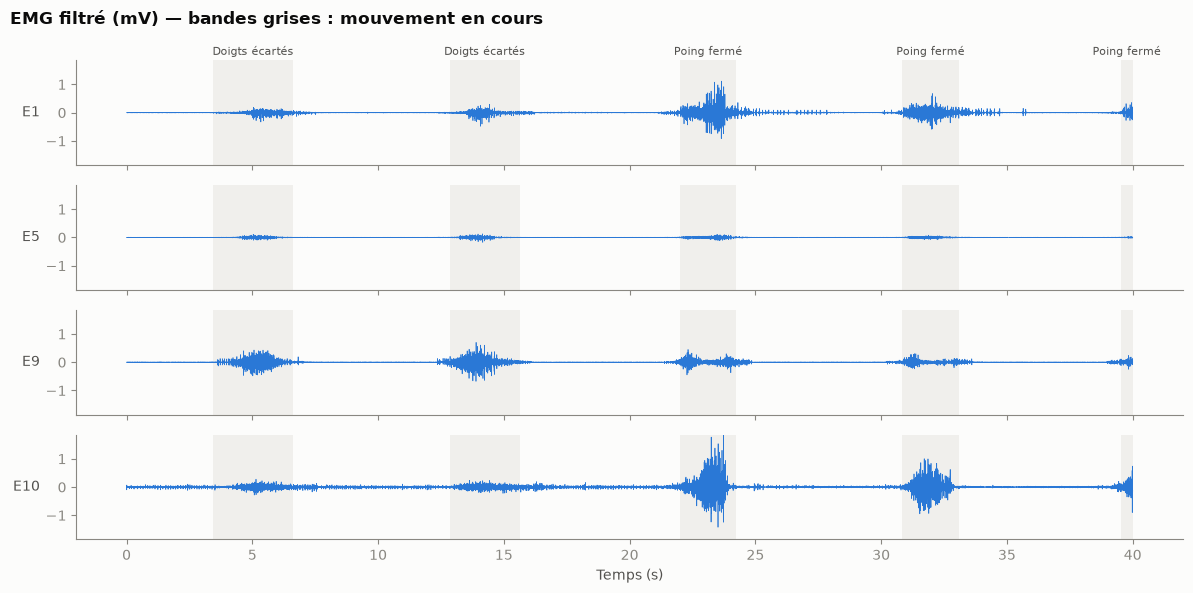

In [5]:
start = np.argmax(labels == 6) - 22 * FS   # fin de « doigts écartés », début de « poing fermé »
seg = slice(start, start + 40 * FS)
t = np.arange(seg.stop - seg.start) / FS
filt = filter_emg(emg[seg])
lab = labels[seg]
channels = [0, 4, 8, 9]

fig, axes = plt.subplots(len(channels), 1, figsize=(12, 6), sharex=True)
lim = np.abs(filt[:, channels]).max() * 1e3
for ax, c in zip(axes, channels):
    moving = lab > 0
    edges = np.flatnonzero(np.diff(np.r_[0, moving.astype(int), 0]))
    for a, b in zip(edges[::2], edges[1::2]):
        ax.axvspan(t[a], t[b - 1], color="#f0efec", lw=0)
    ax.plot(t, filt[:, c] * 1e3, color=BLUE, lw=0.5)
    ax.set_ylim(-lim, lim)
    ax.set_ylabel(ELECTRODES[c].split(" ")[0], rotation=0, ha="right", va="center")
    ax.grid(False)
for a, b in zip(edges[::2], edges[1::2]):
    axes[0].text((t[a] + t[b - 1]) / 2, lim * 1.05, gesture_name(lab[a]),
                 ha="center", va="bottom", fontsize=8, color=INK2)
axes[-1].set_xlabel("Temps (s)")
fig.suptitle("EMG filtré (mV) — bandes grises : mouvement en cours", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
fig.savefig(DOCS / "signal_temporel.png", dpi=150)
plt.show()

## 5. Carte d'activation : quel muscle pour quel geste ?

Pour chaque geste de l'exercice 1, on calcule l'énergie moyenne (RMS) du signal
filtré sur chaque électrode, normalisée par électrode (1 = activation maximale de
cette électrode sur l'ensemble des gestes). C'est une première lecture
**interprétable** de ce que le modèle devra exploiter.

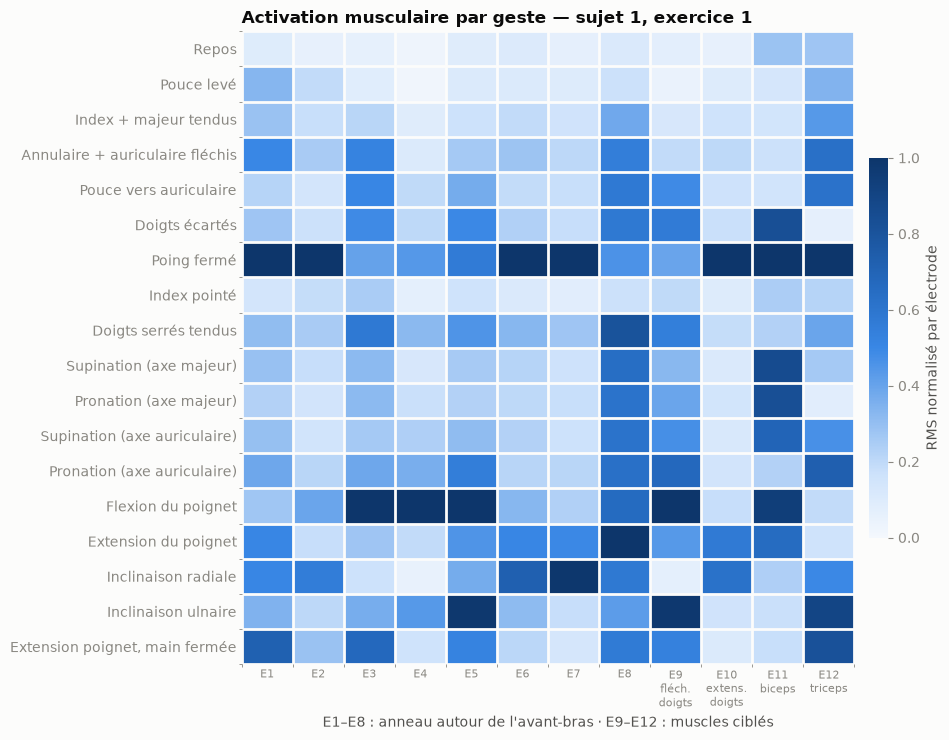

E1 (anneau)                  → surtout : Poing fermé, Extension poignet, main fermée
E2 (anneau)                  → surtout : Poing fermé, Inclinaison radiale
E3 (anneau)                  → surtout : Flexion du poignet, Extension poignet, main fermée
E4 (anneau)                  → surtout : Flexion du poignet, Poing fermé
E5 (anneau)                  → surtout : Flexion du poignet, Inclinaison ulnaire
E6 (anneau)                  → surtout : Poing fermé, Inclinaison radiale
E7 (anneau)                  → surtout : Poing fermé, Inclinaison radiale
E8 (anneau)                  → surtout : Extension du poignet, Doigts serrés tendus
E9 fléchisseur des doigts    → surtout : Flexion du poignet, Inclinaison ulnaire
E10 extenseur des doigts     → surtout : Poing fermé, Inclinaison radiale
E11 biceps                   → surtout : Poing fermé, Flexion du poignet
E12 triceps                  → surtout : Poing fermé, Inclinaison ulnaire


In [6]:
mask = labels <= 17
filt_e1 = filter_emg(emg[mask])
lab_e1 = labels[mask]
gests = np.arange(0, 18)
rms = np.array([np.sqrt(np.mean(filt_e1[lab_e1 == g] ** 2, axis=0)) for g in gests])
rms_norm = rms / rms.max(axis=0, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 7.5))
im = ax.imshow(rms_norm, cmap=BLUES, vmin=0, vmax=1, aspect="auto")
short = [f"E{i}" for i in range(1, 9)] + ["E9\nfléch.\ndoigts", "E10\nextens.\ndoigts", "E11\nbiceps", "E12\ntriceps"]
ax.set_xticks(range(12), short, fontsize=8)
ax.set_xlabel("E1–E8 : anneau autour de l'avant-bras · E9–E12 : muscles ciblés", color=INK2)
ax.set_yticks(range(len(gests)), [gesture_name(g) for g in gests])
ax.tick_params(length=0)
ax.set_xticks(np.arange(-0.5, 12), minor=True)
ax.set_yticks(np.arange(-0.5, len(gests)), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.grid(which="major", visible=False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cb.set_label("RMS normalisé par électrode", color=INK2)
cb.outline.set_visible(False)
ax.set_title("Activation musculaire par geste — sujet 1, exercice 1")
plt.tight_layout()
fig.savefig(DOCS / "carte_activation.png", dpi=150)
plt.show()

for c in range(12):
    top = gests[np.argsort(rms_norm[:, c])[::-1][:2]]
    print(f"{ELECTRODES[c]:28s} → surtout : {', '.join(gesture_name(g) for g in top)}")

## Conclusions

- **Déséquilibre** : le repos occupe la majorité du temps → métrique principale =
  accuracy équilibrée, et une attention particulière aux confusions repos / geste
  (un faux « repos » = la prothèse ne répond pas ; un faux geste = elle bouge seule).
- **Filtrage** justifié par le spectre : l'énergie utile est bien dans 20–450 Hz.
- Le **poing fermé** active presque toutes les électrodes au maximum : geste
  « facile ». Les gestes fins d'un doigt (index pointé, pouce levé) produisent
  une activation faible, proche du repos → plus difficiles à reconnaître.
- **Motifs d'activation distincts** selon les gestes, surtout entre gestes du
  poignet et gestes des doigts ; certains gestes voisins (ex. supination/pronation
  selon les deux axes) ont des cartes proches → confusions attendues.
- Prochaine étape : baseline Hudgins + LDA (référence des prothèses commerciales),
  puis CNN 1D sur les fenêtres de 200 ms.